# Nonlinear State-Space Model for USV Surge and Yaw

This notebook identifies a coupled, nonlinear state-space model of USV dynamics.
It represents the second level of model complexity in the hierarchy:

| Level | Model | Complexity |
|-------|-------|------------|
| 1 | First-order SISO (surge, yaw) | Lowest — linear, decoupled |
| **2** | **Nonlinear state-space** | **Mid — physical structure, nonlinear drag** |
| 3 | Black-box (ML) | Highest — no assumed structure |

Following Box's principle that *all models are wrong, but some are useful*, this model
retains physical interpretability while adding the dominant nonlinearity identified in
the diagnostics: quadratic hydrodynamic drag.

---
> **Data limitation notice**
>
> This analysis is based on a single 130-second step-response trial covering a limited
> operating envelope (throttle 0–39%, speed 0–3 m/s, moderate rudder inputs).
> It serves as a proof-of-concept for the identification workflow.
> When richer datasets are available — multiple runs, wider throttle and rudder ranges,
> and dedicated speed-hold experiments — the same procedure will produce parameter
> estimates that better cover the full operating envelope and allow validation of
> speed-dependent effects not resolvable here.

---

## Model equations

Treating the vessel as a planar rigid body and neglecting sway (justified for
low-speed straight-line and moderate turning maneuvers), the equations of motion are:

$$\dot{v} = k_T \, u - d_2 \, v|v| \tag{surge}$$

$$\dot{r} = k_\delta \, \delta - d_r \, r \tag{yaw}$$

| Symbol | Meaning | Units |
|--------|---------|-------|
| $v$ | surge speed | m/s |
| $r$ | yaw rate | rad/s |
| $u$ | throttle command | — (norm.) |
| $\delta$ | rudder command | — (norm.) |
| $k_T$ | thrust coefficient | m/s² per unit throttle |
| $d_2$ | quadratic drag coefficient | m⁻¹ |
| $k_\delta$ | rudder moment coefficient | rad/s² per unit rudder |
| $d_r$ | yaw damping coefficient | s⁻¹ |

The $v|v|$ term ensures the drag force opposes motion in both directions even though
the current dataset contains only forward speed.
The two equations remain decoupled, which the diagnostics support given this dataset;
speed-dependent rudder effectiveness ($k_\delta \propto v$) could not be resolved
with the available data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.integrate

DATA_CSV = 'usv_step_response_150_280s.csv'
DT = 0.1

## 1. Load data

In [2]:
df    = pd.read_csv(DATA_CSV)
t     = df['time_s'].to_numpy()
u     = df['throttle_norm'].to_numpy()
delta = df['rudder_norm'].to_numpy()
v     = df['speed_mps'].to_numpy()
r     = df['yaw_rate_rps'].to_numpy()

print(f'{len(t)} samples  |  {t[-1]:.0f} s  |  {1/DT:.0f} Hz')
print(f'Speed  : {v.min():.2f} – {v.max():.2f} m/s')
print(f'Throttle: {u.min():.2f} – {u.max():.2f}  (max possible: 1.0)')
print(f'Rudder  : {delta.min():.2f} – {delta.max():.2f}')

1300 samples  |  130 s  |  10 Hz
Speed  : 0.02 – 2.92 m/s
Throttle: 0.00 – 0.39  (max possible: 1.0)
Rudder  : -1.00 – 0.69


## 2. Surge parameter identification — two-phase approach

A joint least-squares fit on noisy finite differences conflates thrust and drag,
pulling `d2` well below its physical value. Instead we use a two-phase approach
that treats the two parameters independently:

**Phase 1 — coasting** (`u ≈ 0`): thrust is zero, so only drag acts.
$$\dot{v} = -d_2 v^2 \quad \Rightarrow \quad d_2 = \frac{-\dot{v}}{v^2}$$
Least-squares fit on zero-throttle segments gives a clean drag estimate
uncontaminated by thrust.

**Phase 2 — powered** (`u > 0`): with `d2` fixed from Phase 1, solve for `k_T`:
$$k_T = \frac{\dot{v} + d_2 v^2}{u}$$

> **Data note:** The thrust coefficient $k_T$ is identified as a single linear gain.
> A nonlinear thrust curve requires steady-state data across the full throttle range;
> the current trial reaches only 39% throttle.

In [3]:
COAST_THRESH  = 0.01   # throttle below this is treated as zero thrust
POWERED_THRESH = 0.05  # throttle above this is treated as powered

coast_mask   = (u < COAST_THRESH)  & (t > 2.0) & (t < t[-1] - 2.0)
powered_mask = (u > POWERED_THRESH) & (t > 2.0) & (t < t[-1] - 2.0)

# Numerical derivative (central differences — less noisy than forward diff)
v_dot = np.gradient(v, DT)

# ── Phase 1: drag from coasting ─────────────────────────────────────────
v_c    = v[coast_mask]
vdot_c = v_dot[coast_mask]

# Regress: -v_dot = d2 * v^2  (force positive d2)
d2 = np.dot(v_c**2, -vdot_c) / np.dot(v_c**2, v_c**2)

print(f'Phase 1 — coasting ({coast_mask.sum()} samples, {coast_mask.sum()*DT:.1f} s):')
print(f'  d2 = {d2:.4f}  m⁻¹')

# ── Phase 2: thrust from powered segments ───────────────────────────────
v_p    = v[powered_mask]
vdot_p = v_dot[powered_mask]
u_p    = u[powered_mask]

# Regress: (v_dot + d2*v^2) = k_T * u
lhs = vdot_p + d2 * v_p**2
k_T = np.dot(u_p, lhs) / np.dot(u_p, u_p)

print(f'\nPhase 2 — powered ({powered_mask.sum()} samples, {powered_mask.sum()*DT:.1f} s):')
print(f'  k_T = {k_T:.4f}  m/s² per unit throttle')

v_ss_max = np.sqrt(k_T / d2)
print(f'\nImplied max speed at full throttle: {v_ss_max:.2f} m/s')
print(f'  (observed max: {v.max():.2f} m/s at {u.max():.0%} throttle)')

Phase 1 — coasting (352 samples, 35.2 s):
  d2 = 0.4377  m⁻¹

Phase 2 — powered (908 samples, 90.8 s):
  k_T = 3.9628  m/s² per unit throttle

Implied max speed at full throttle: 3.01 m/s
  (observed max: 2.92 m/s at 39% throttle)


## 3. Yaw parameter identification

The yaw equation is linear:
$$\dot{r} = k_\delta \, \delta - d_r \, r$$

The parameters are directly related to the first-order model
already identified (`tau_r`, `K_r`):
$$d_r = \frac{1}{\tau_r}, \qquad k_\delta = \frac{K_r}{\tau_r}$$

We re-derive them here via the same finite-difference least-squares approach
for consistency with the surge identification.

> **Data note:** Speed-dependent rudder effectiveness ($k_\delta \propto v$) was
> not supported by the available data (diagnostic 1 showed no improvement).
> Resolving that coupling requires dedicated experiments: fixed-speed runs with
> rudder sweeps at several distinct surge speeds.

In [4]:
r_dot_meas = np.diff(r) / DT

Phi_r = np.column_stack([delta[:-1], -r[:-1]])
params_r, _, _, _ = scipy.linalg.lstsq(Phi_r, r_dot_meas)
k_delta, d_r = params_r

# Equivalent first-order parameters for cross-check
tau_r_check = 1.0 / d_r
K_r_check   = k_delta / d_r

print(f'Yaw parameters (LS on derivatives):')
print(f'  k_delta = {k_delta:.4f}  rad/s² per unit rudder')
print(f'  d_r     = {d_r:.4f}  s⁻¹')
print(f'\nEquivalent first-order parameters:')
print(f'  tau_r = 1/d_r  = {tau_r_check:.3f} s   (ARX fit: 0.471 s)')
print(f'  K_r   = kδ/d_r = {K_r_check:.3f}       (ARX fit: 0.771 rad/s)')

Yaw parameters (LS on derivatives):
  k_delta = 1.4736  rad/s² per unit rudder
  d_r     = 1.9117  s⁻¹

Equivalent first-order parameters:
  tau_r = 1/d_r  = 0.523 s   (ARX fit: 0.471 s)
  K_r   = kδ/d_r = 0.771       (ARX fit: 0.771 rad/s)


## 4. Simulate and validate

Integrate the nonlinear ODE system forward using the measured throttle and rudder
sequences as inputs, starting from the measured initial conditions.
The ODE is solved with RK45 between each 0.1 s sample, with inputs held constant
within each interval (zero-order hold).

In [5]:
def usv_ode(t_local, state, u_in, delta_in):
    v_s, r_s = state
    dv = k_T * u_in    - d2    * v_s * abs(v_s)
    dr = k_delta * delta_in - d_r * r_s
    return [dv, dr]

# Step-by-step integration (ZOH inputs)
state = np.zeros((len(t), 2))
state[0] = [v[0], r[0]]

for k in range(len(t) - 1):
    sol = scipy.integrate.solve_ivp(
        usv_ode,
        t_span=[0, DT],
        y0=state[k],
        args=(u[k], delta[k]),
        method='RK45',
        dense_output=False
    )
    state[k+1] = sol.y[:, -1]

v_sim = state[:, 0]
r_sim = state[:, 1]

rmse_v = np.sqrt(np.mean((v - v_sim)**2))
rmse_r = np.sqrt(np.mean((r - r_sim)**2))
r2_v   = 1 - np.sum((v - v_sim)**2) / np.sum((v - v.mean())**2)
r2_r   = 1 - np.sum((r - r_sim)**2) / np.sum((r - r.mean())**2)

print(f'Surge:    RMSE = {rmse_v:.4f} m/s    R² = {r2_v:.4f}')
print(f'Yaw rate: RMSE = {rmse_r:.4f} rad/s  R² = {r2_r:.4f}')

Surge:    RMSE = 0.1657 m/s    R² = 0.9086
Yaw rate: RMSE = 0.0828 rad/s  R² = 0.8198


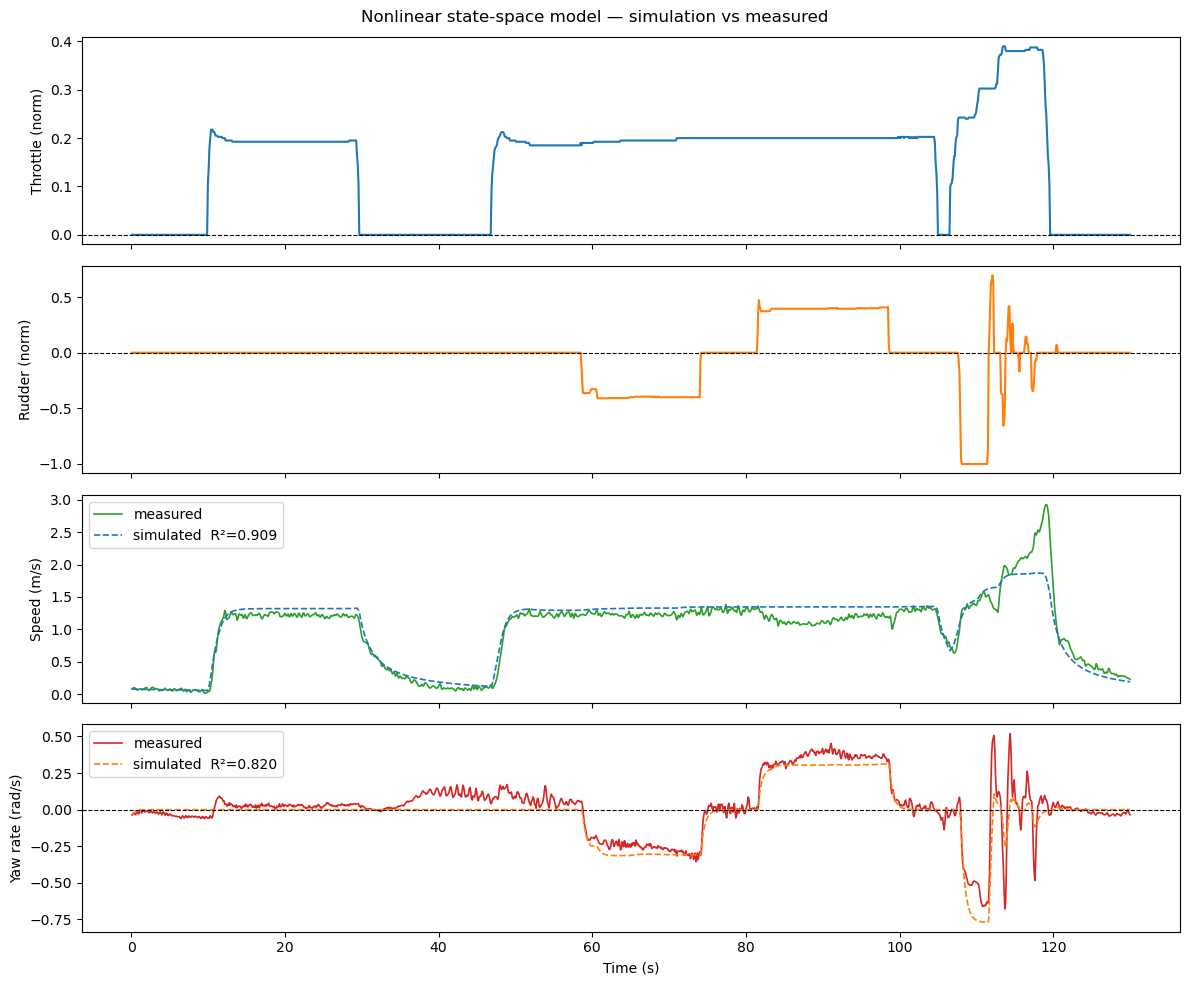

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Nonlinear state-space model — simulation vs measured', fontsize=12)

axes[0].plot(t, u,     color='C0'); axes[0].set_ylabel('Throttle (norm)')
axes[0].axhline(0, color='k', lw=0.8, ls='--')

axes[1].plot(t, delta, color='C1'); axes[1].set_ylabel('Rudder (norm)')
axes[1].axhline(0, color='k', lw=0.8, ls='--')

axes[2].plot(t, v,     color='C2', lw=1.2, label='measured')
axes[2].plot(t, v_sim, color='C0', lw=1.2, ls='--', label=f'simulated  R²={r2_v:.3f}')
axes[2].set_ylabel('Speed (m/s)'); axes[2].legend()

axes[3].plot(t, r,     color='C3', lw=1.2, label='measured')
axes[3].plot(t, r_sim, color='C1', lw=1.2, ls='--', label=f'simulated  R²={r2_r:.3f}')
axes[3].axhline(0, color='k', lw=0.8, ls='--')
axes[3].set_ylabel('Yaw rate (rad/s)'); axes[3].legend()
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 5. Parameter summary and model comparison

The table below compares the nonlinear model parameters against their
equivalents from the first-order SISO models.

In [7]:
print('Identified nonlinear state-space model')
print('=' * 45)
print(f'  dv/dt = {k_T:.4f}·u  -  {d2:.4f}·v|v|')
print(f'  dr/dt = {k_delta:.4f}·δ  -  {d_r:.4f}·r')
print()
print('Model comparison (fit quality)')
print('-' * 45)
print(f'{'':25s}  {'R² surge':>10s}  {'R² yaw':>10s}')
print(f'  First-order SISO (ARX)  :  {'0.9295':>10s}  {'0.8261':>10s}')
print(f'  Nonlinear state-space   :  {r2_v:>10.4f}  {r2_r:>10.4f}')
print()
print('Data coverage note')
print('-' * 45)
print(f'  Speed range observed  : {v.min():.2f} – {v.max():.2f} m/s')
print(f'  Throttle range        : {u.min():.2f} – {u.max():.2f}  (of 0–1.0 possible)')
print(f'  Rudder range          : {delta.min():.2f} – {delta.max():.2f}  (of -1.0–1.0 possible)')
print(f'  Duration              : {t[-1]:.0f} s  (single trial)')
print()
print('  Parameters kT and d2 extrapolate beyond the observed envelope.')
print('  Expanded data collection will refine these estimates and may')
print('  reveal additional nonlinearities (thrust saturation, deadband,')
print('  speed-dependent rudder gain) not resolvable with this trial.')

Identified nonlinear state-space model
  dv/dt = 3.9628·u  -  0.4377·v|v|
  dr/dt = 1.4736·δ  -  1.9117·r

Model comparison (fit quality)
---------------------------------------------
                             R² surge      R² yaw
  First-order SISO (ARX)  :      0.9295      0.8261
  Nonlinear state-space   :      0.9086      0.8198

Data coverage note
---------------------------------------------
  Speed range observed  : 0.02 – 2.92 m/s
  Throttle range        : 0.00 – 0.39  (of 0–1.0 possible)
  Rudder range          : -1.00 – 0.69  (of -1.0–1.0 possible)
  Duration              : 130 s  (single trial)

  Parameters kT and d2 extrapolate beyond the observed envelope.
  Expanded data collection will refine these estimates and may
  reveal additional nonlinearities (thrust saturation, deadband,
  speed-dependent rudder gain) not resolvable with this trial.
